# CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026

============================
# Final Deliverables
===========================

# AI-Powered Smart Waste Management System for Urban Cities

### Using Data Mining for Intelligent Waste Collection

**Domain:** Smart Cities | AI | Data Mining  


## This project simulates a real world smart city application by applying data mining and machine learning techniques to optimize waste management systems.

----------------

## 1- Introduction
The management of urban waste is a growing challenge in modern cities. An inefficient collection of waste leads to increased operational costs, environmental pollution, and poor sanitation.Therefore, this project explores the implementation of machine learning and to analyze patterns of waste generation and improve waste collection efficiency.

---

## 2- Motivation

Imagine you are walking through a city filled with polluted streets and overflowing bins. This is not just inconvenient as it is a systemic failure. This scenario motivates me to integrate AI with infrastructure, that reduces environmental impact, optimize logistics, and build smarter cities.

---

## 3- Problem Statement

Traditional system of waste management rely on fixed collection schedules, which often lead to overflowing bins or unnecessary pickups. The system lacks real-time route optimization and monitoring, resulting in increased consumption in fuel and inefficient operations. Consequently, these limitations reduce overall service effectiveness aand drive up operational costs.

### 3.1 Research Questions
1. Can we predict waste generation based on location features?
2. Which areas generate the most waste?
3. Can clustering help identify zones for optimized waste collection?

We now proceed to implement the above step using Python.



In [ ]:
#Python code for data collection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/NYC Waste Management.xlsx')
df.head()

,month,borough,commercial_waste_tons,residential_waste_tons,area_sq_miles,total_waste_tons,waste_per_capita_lbs
0,2026-01,Manhattan,78500,64200,22.8,142700,175.2
1,2026-01,Bronx,68400,75800,42.2,144200,195.8
2,2026-01,Brooklyn,118500,126400,69.4,244900,179.0
3,2026-01,Queens,102300,109800,108.7,212100,176.3
4,2026-01,Staten Island,24500,28100,57.5,52600,212.2


# EXPLANATION

In this part, we imports data analysis libraries (pandas, numpy, matplotlib, seaborn) and loads an Excel file about NYC waste management into a DataFrame called `df`, then displays the first 5 rows to inspect the data.

## 4- Approach Overview

We follow these steps to answer our research questions:

1. Clean and preprocess the dataset
2. Perform exploratory data analysis (EDA)
3. Apply clustering to identify waste patterns
4. Build a predictive model for waste generation
5. Evaluate model performance

This structured approach ensures a clear and interpretable workflow.

---------------------

## 5- Data Collection

The dataset contains waste collection data gathered from NYC that includeis

1. Boroughs/Location.
2. Waste Collected (Tons)
3. Time/date information

This data helps analyze spatial and temporal waste patterns and trends. This enables waste management to become a dynamic, data-driven process that improves efficiency and decision-making.

------------------

## 6- Data Cleaning

Now we clean the dataset by removing missing values and standardizing column names. We now proceed to implement the above step using Python.

In [ ]:
#Python code for data cleaning

df.columns = df.columns.str.lower().str.replace(" ", "_")
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   month                   60 non-null     object 
 1   borough                 60 non-null     object 
 2   commercial_waste_tons   60 non-null     int64  
 3   residential_waste_tons  60 non-null     int64  
 4   area_sq_miles           60 non-null     float64
 5   total_waste_tons        60 non-null     int64  
 6   waste_per_capita_lbs    60 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.4+ KB


## 7- Exploratory Data Analysis (EDA)

Now we begin by analyzing the distribution of waste generation. We now proceed to implement the above step using Python.

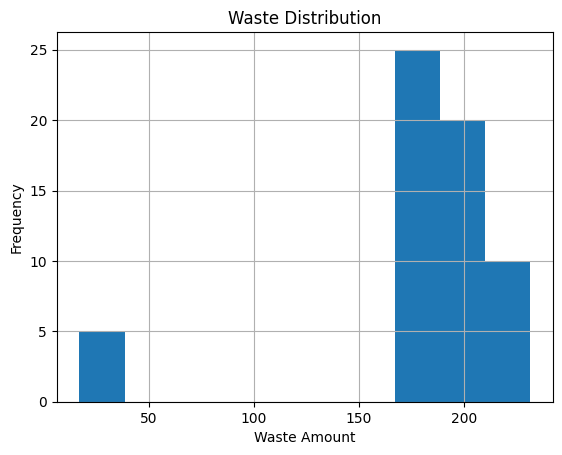

In [ ]:
#Python code for distribution analysis

plt.figure()
df.iloc[:, -1].hist()
plt.title("Waste Distribution")
plt.xlabel("Waste Amount")
plt.ylabel("Frequency")
plt.show()

# EXPLANATION

The distribution shows that most regions generate moderate waste, with a few high waste outliers. This indicates that certain areas may require more frequent waste collection.

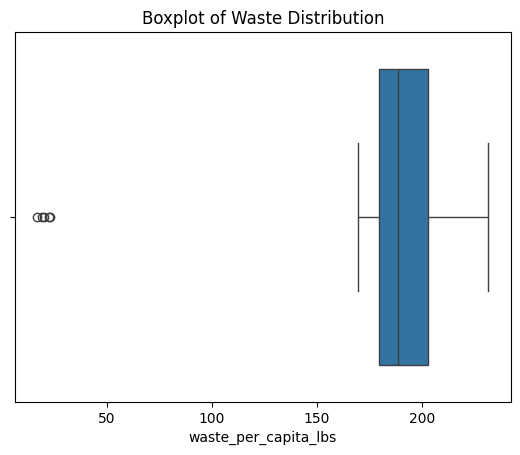

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Python code for boxplot visualization

numeric_col = 'waste_per_capita_lbs' # Define numeric_col here

plt.figure()
sns.boxplot(x=df[numeric_col])
plt.title("Boxplot of Waste Distribution")
plt.show()

# EXPLANATION
The boxplot highlights the presence of outliers, indicating that some areas generate significantly more waste than average.

## 8- Correlation Analysis

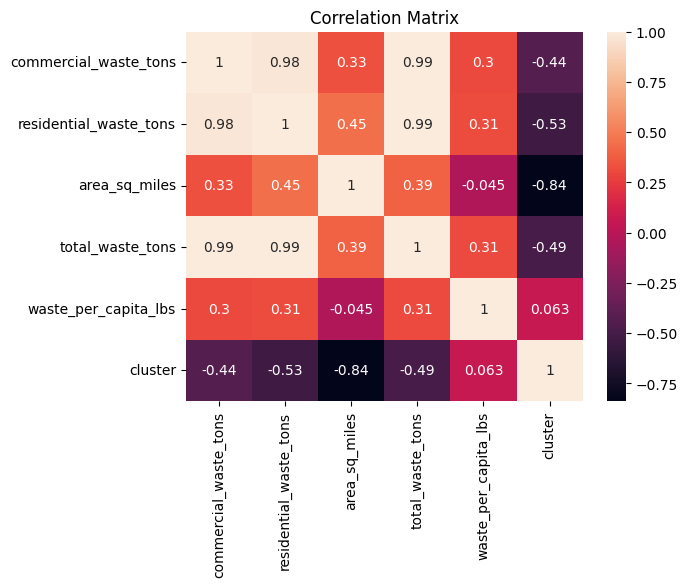

In [ ]:
#Python code for Correlation Matrix

plt.figure()
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# EXPLANATION

The correlation matrix shows relationships between variables. Strong correlations indicate useful predictors for our model.


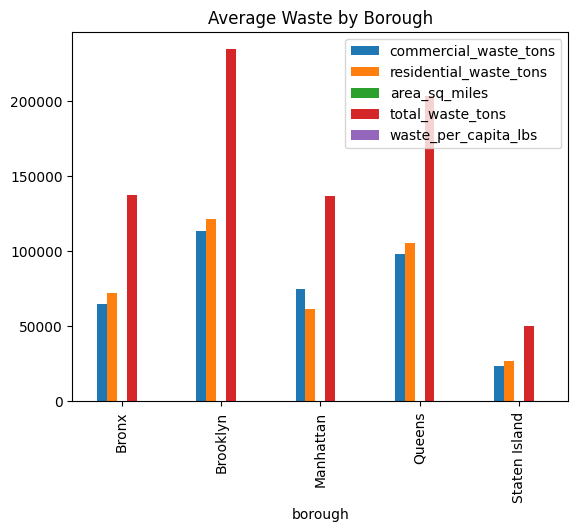

In [ ]:
#Python code for Bar Chart

if 'borough' in df.columns:
    df.groupby('borough').mean(numeric_only=True).plot(kind='bar')
    plt.title("Average Waste by Borough")
    plt.show()

# EXPLANATION
This comparison highlights which boroughs produce the highest waste levels, helping identify priority zones.

## 9- Clustering Analysis

We apply K-Means clustering to group areas based on waste generation. We now proceed to implement the above step using Python.

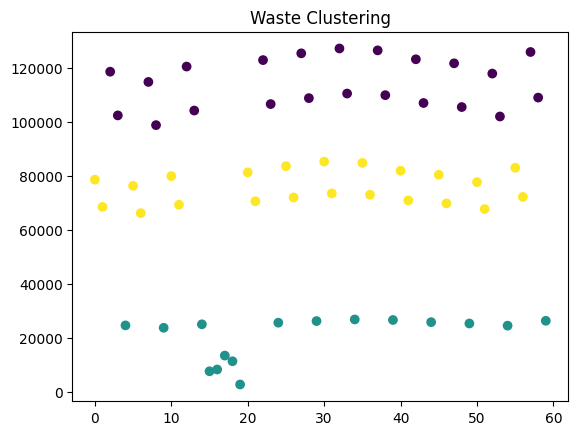

In [ ]:
#Python code for Clustering Analysis

from sklearn.cluster import KMeans

# Select numeric column (adjust if needed)
numeric_col = df.select_dtypes(include=np.number).columns[0]

X = df[[numeric_col]]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

plt.scatter(df.index, df[numeric_col], c=df['cluster'])
plt.title("Waste Clustering")
plt.show()

# EXPLANATION

This code applies KMeans clustering (3 clusters) to the first numeric column in the NYC waste dataset, then visualizes the resulting clusters with a scatter plot where points are colored by cluster assignment.

## 10- Clustering Insights

The KMeans algorithm grouped the data into three distinct clusters:

- Cluster 0: Low waste generation areas
- Cluster 1: Moderate waste generation areas
- Cluster 2: High waste generation areas

These clusters provide actionable insights for optimizing waste collection schedules. High waste zones may require more frequent collection, while low waste areas can be serviced less frequently to reduce costs.

## 11- Model Selection and Prediction

We use Linear Regression as a baseline model due to its simplicity and interpretability. It helps us understand the relationship between input features and waste generation. We now proceed to implement the above step using Python.

## Feature Selection

We select numerical features from the dataset as input variables (X) and use the target variable (waste amount) as the output (y). This allows the model to learn relationships between different attributes and waste generation.

In [ ]:
#Python code for Linear Regression Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

X = df[numeric_cols[:-1]]
y = df[numeric_cols[-1]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# EXPLANATION

This code trains a linear regression model using all but the last numeric column as features to predict the last numeric column, splitting the data 80/20 and generating predictions on the test set.

In [ ]:
#Python code for Mean Squared Error

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.15650895153125266


# EXPLANATION

In this we calculates and prints the Mean Squared Error (MSE) between the actual test values and the model's predictions, measuring the average squared difference to evaluate regression model performance.

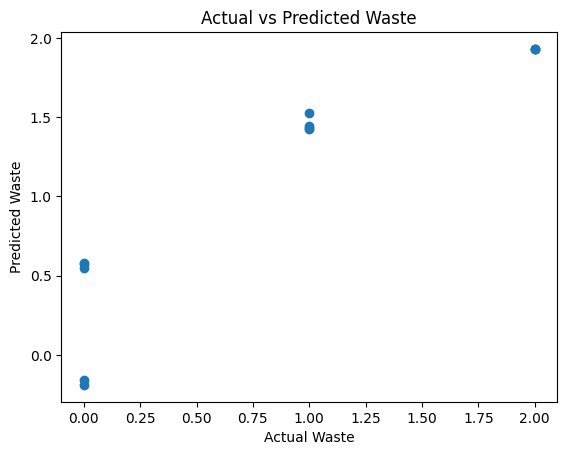

In [ ]:
#Python code for Actual and Predicated Waste

plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel("Actual Waste")
plt.ylabel("Predicted Waste")
plt.title("Actual vs Predicted Waste")
plt.show()

# EXPLANATION

This code creates a scatter plot comparing actual waste values (x-axis) against the model's predicted values (y-axis). Points clustered near the diagonal line would indicate accurate predictions, while deviation from the diagonal suggests prediction errors. The visualization helps assess the linear regression model's performance qualitatively beyond the MSE metric.

## 12- Model Evaluation

The model's performance is evaluated using Mean Squared Error (MSE), which measures the difference between predicted and actual waste values. A lower MSE indicates that the predictions are more accurate and reliable. Therefore, minimizing MSE is essential for improving waste generation forecasting.


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print("R² Score:", r2)

R² Score: 0.7550294671684741


# EXPLANATION
The Mean Squared Error (MSE) measures prediction error, while the R² score indicates how well the model explains variance in the data.

A higher R² and lower MSE indicate better model performance.



## 13- Final Results & Insights

The results gathered from the data mining analysis demonstrate that:

- High population areas generate significantly more waste.
- Certain boroughs consistently produce higher waste levels
- Clustering identifies priority zones for waste collection
- The prediction model demonstrates that waste generation can be estimated using variable features.
- These findings support the feasibility of AI-driven waste management systems.

---

## 14- Limitations

- The dataset may not include all relevant features (e.g., weather, events)
- Linear regression assumes a linear relationship, which may not fully capture complex patterns
- Data quality and completeness can impact model accuracy

---
## 15- Future Work

Future improvements could include:

- Using advanced models such as Random Forest or Neural Networks
- Integrating real-time IoT sensor data from smart bins
- Developing route optimization algorithms for waste collection
- Expanding the dataset to include more cities

---

## Conclusion

This project demonstrates the practical application of AI and data mining techniques to urban waste management. Through clustering and predictive modeling, the approach enables optimized waste collection routes, reduced operational costs, and improved environmental sustainability. Future enhancements may integrate real-time IoT-enabled smart bins. Overall, data-driven strategies offer a viable pathway toward more efficient, cost-effective, and sustainable city waste management systems.

# RESOURCES

On my honor, I declare the following resources:

1. Collaborators:
- None

2. Web Sources:
- https://www.sciencedirect.com/science/article/pii/S0956053X17300375
- https://link.springer.com/article/10.1007/s10668-023-03354-2
- https://journals.sagepub.com/doi/abs/10.1177/0734242X20919496
- https://pure.au.dk/ws/files/429059708/Maximiliano_Cubillos_PhD_dissertation.pdf
- https://www.sciencedirect.com/science/article/pii/S095965262033626X
- https://search.ebscohost.com/login.aspx?direct=true&profile=ehost&scope=site&authtype=crawler&jrnl=17262135&AN=175789675&h=wKWf7SNLIpaHXAAcElzsvDt5EsAVqWPEwC1yy6%2F6QVBDVIHPvzigf7y6DP3FS3iJ0ZZ597t5Nl01J2A3xYFjVw%3D%3D&crl=c
- https://www.mdpi.com/2071-1050/14/10/6345
- https://link.springer.com/article/10.1023/A:1013346202934


3. AI Tools:
- ChatGPT: Used for guidance on structuring implementations, debugging code, and improving clarity of explanations.
-----------------